# Portfolio size vs a momentum strategy

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots, signals
from algo_trading.backtest.config import FEE_BPS, PortfolioConfig

plots.apply_theme()

LOOKBACK = 64                  # momentum window, in days
BUY, SELL = 0.5, -0.5          # buy above +20% momentum, sell below 0%
WARMUP = LOOKBACK              # first bar with a momentum value
N_POSITIONS = [1, 5, 10, 15]   # max names held at once, each sized 1/N
SEED = 0                       # random pick when more names qualify than free slots
FEE = 0                        # per fill in bps; FEE_BPS is 0.2% (buy AND sell)
INITIAL = 10_000
CFG = PortfolioConfig(check_bars=1, rebalance=False)   # buy once, hold until the exit signal
COLORS = plots.ramp(len(N_POSITIONS))

## Data

In [10]:
panel = data.daily_panel()
close = panel.close
print(panel.describe())

854 1d bars x 27 tokens  2024-05-26 00:00:00+00:00 -> 2026-09-26 00:00:00+00:00


## Signal

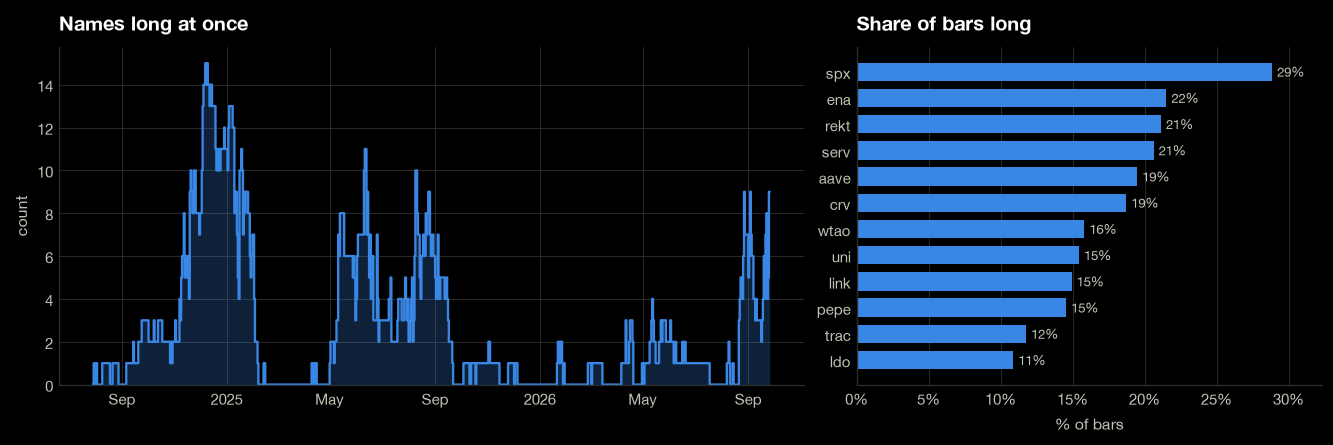

In [11]:
enter, exit_, mom = signals.momentum_thresholds(close, LOOKBACK, BUY, SELL)


def top_n(n: int, seed: int = SEED) -> pd.DataFrame:
    """Up to n names at 1/n: buy when momentum > BUY and a slot is free, sell when < SELL."""
    return bt.slot_weights(enter, n, seed=seed, exit=exit_)


plots.exposure(enter.astype(float), start=WARMUP, top=12)
plt.show()

## Backtest across portfolio sizes

In [12]:
runs, rows = {}, []
for n in N_POSITIONS:
    label = f"top {n}"
    res = bt.simulate(close, top_n(n), CFG, fee_bps=FEE, initial=INITIAL, warmup=WARMUP)
    row = bt.stats_from_result(res, label, WARMUP, panel.bars_per_year)
    row["final_$"] = res["equity"].iloc[-1]
    row["avg_held"] = res["log"].n_held.mean()
    runs[label], rows = res, rows + [row]


def buy_and_hold(growth: pd.Series, label: str) -> dict:
    eq = growth / growth.iloc[WARMUP] * INITIAL
    row = bt.perf(eq, label, start=WARMUP, initial=INITIAL, gross=1.0,
                  bars_per_year=panel.bars_per_year)
    row["final_$"], row["avg_held"] = eq.iloc[-1], float("nan")
    return row


bench = [buy_and_hold(data.equal_weight_bh(close), "equal-weight buy & hold"),
         buy_and_hold(close["wbtc"], "WBTC buy & hold")]

table = pd.DataFrame(rows + bench).set_index("label")
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "vol", "max_dd", "n_fills", "fees_pct",
                    "avg_held", "gross"]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}", "avg_held": "{:.1f}"})

,final_$,total_ret,sharpe,vol,max_dd,n_fills,fees_pct,avg_held,gross
label,,,,,,,,,
top 1,"$6,728",-32.7%,0.33,104%,-66.8%,5,0.00%,1.0,98%
top 5,"$38,275",+282.8%,1.09,107%,-78.3%,33,0.00%,3.9,77%
top 10,"$25,303",+153.0%,0.91,92%,-74.2%,48,0.00%,6.8,68%
top 15,"$18,142",+81.4%,0.74,84%,-76.7%,67,0.00%,10.0,71%
equal-weight buy & hold,"$24,744",+147.4%,0.93,118%,-82.7%,0,0.00%,—,100%
WBTC buy & hold,"$12,346",+23.5%,0.44,46%,-53.1%,0,0.00%,—,100%


## Equity

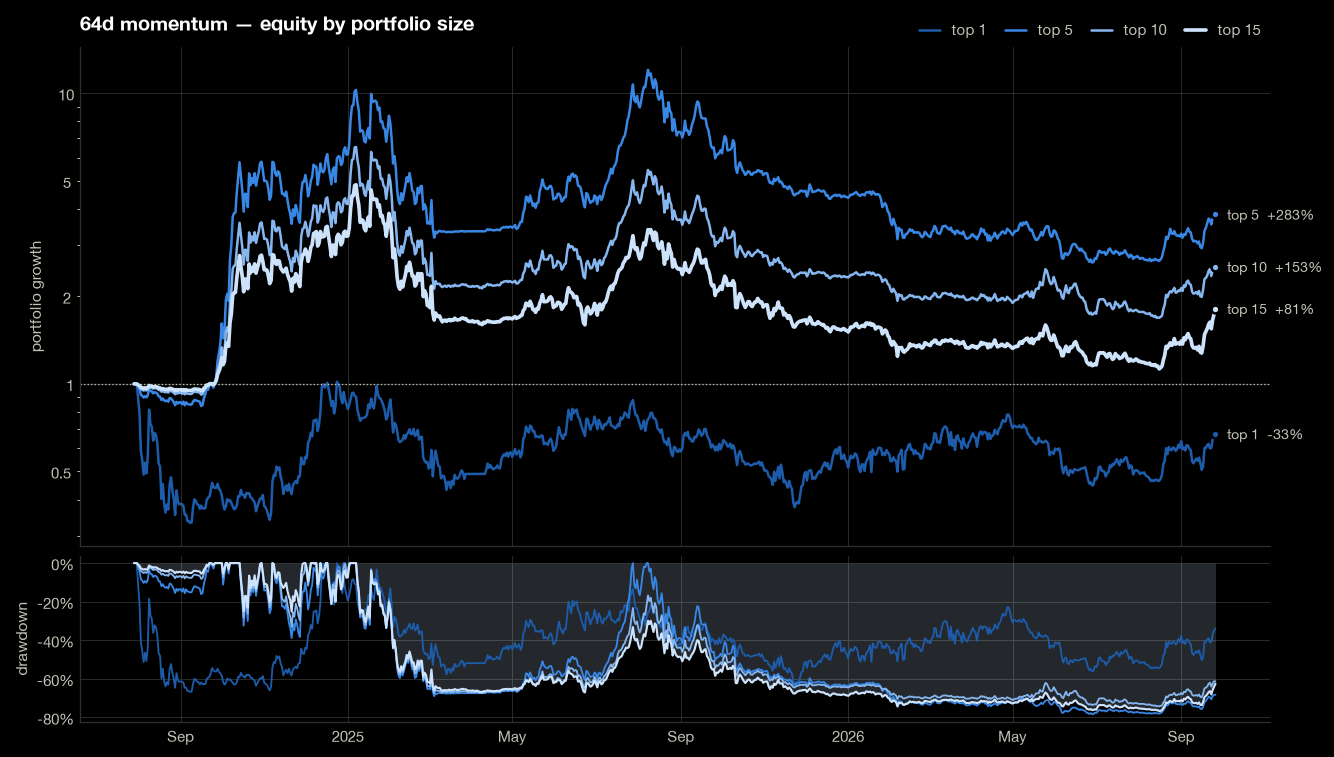

In [13]:
plots.equity_drawdown({k: r["equity"].iloc[WARMUP:] for k, r in runs.items()},
                      f"{LOOKBACK}d momentum — equity by portfolio size", log=True,
                      colors=COLORS, dd_for=f"top {N_POSITIONS[-1]}")
plt.show()

## Return and Sharpe vs portfolio size

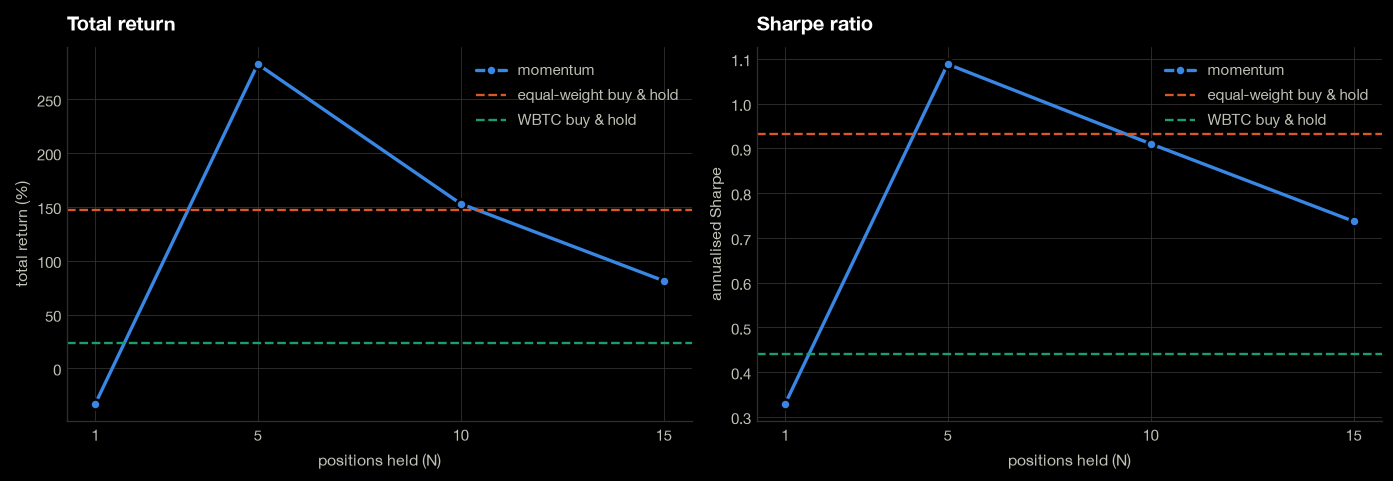

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), layout="constrained")
plots.sweep(N_POSITIONS, {"momentum": [r["total_ret"] * 100 for r in rows]},
            "Total return", "positions held (N)", "total return (%)",
            hlines={b["label"]: b["total_ret"] * 100 for b in bench}, ax=axes[0])
plots.sweep(N_POSITIONS, {"momentum": [r["sharpe"] for r in rows]},
            "Sharpe ratio", "positions held (N)", "annualised Sharpe",
            hlines={b["label"]: b["sharpe"] for b in bench}, ax=axes[1])
for ax in axes:
    ax.set_xticks(N_POSITIONS)
plt.show()

## Portfolio size by momentum lookback

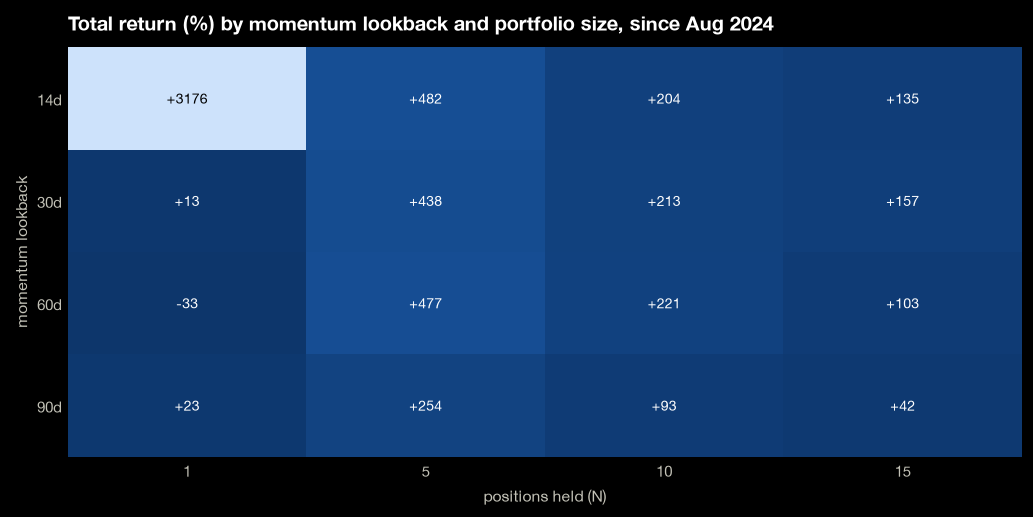

In [15]:
LOOKBACKS = [14, 30, 60, 90]
GRID_WARMUP = max(LOOKBACKS)   # common scoring window for every lookback

grid = {}
for lb in LOOKBACKS:
    en, ex, _ = signals.momentum_thresholds(close, lb, BUY, SELL)
    results = bt.simulate_many(close, [bt.slot_weights(en, n, seed=SEED, exit=ex)
                                       for n in N_POSITIONS],
                               CFG, fee_bps=FEE, initial=INITIAL, warmup=GRID_WARMUP)
    grid[f"{lb}d"] = {n: (r["equity"].iloc[-1] / r["equity"].iloc[GRID_WARMUP] - 1) * 100
                      for n, r in zip(N_POSITIONS, results)}

surface = pd.DataFrame(grid).T
since = close.index[GRID_WARMUP].strftime("%b %Y")
plots.heatmap(surface, f"Total return (%) by momentum lookback and portfolio size, since {since}",
              fmt="{:+.0f}", xlabel="positions held (N)", ylabel="momentum lookback",
              figsize=(8.5, 4.2))
plt.show()

## Video: portfolio size under three momentum thresholds

In [16]:
import tempfile
from pathlib import Path

from IPython.display import Video

from algo_trading.backtest import animate
from algo_trading.backtest.config import PROJECT_ROOT

BRAND = PROJECT_ROOT.parent / "public"   # local brand assets; not part of this repo
FONT = BRAND / "fonts" / "alliance-no1" / "Degarism Studio - Alliance No.1 Light.otf"
ICON = BRAND / "hpt-icon-purple.svg"

PAIRS = [(0.0, 0.0), (0.5, 0.0), (1.0, 0.0)]   # (buy, sell) momentum thresholds, one race each

summary, parts = {}, []
with tempfile.TemporaryDirectory() as tmp:
    for k, (buy, sell) in enumerate(PAIRS, 1):
        en, ex, _ = signals.momentum_thresholds(close, LOOKBACK, buy, sell)
        results = bt.simulate_many(close, [bt.slot_weights(en, n, seed=SEED, exit=ex)
                                           for n in N_POSITIONS],
                                   CFG, fee_bps=FEE, initial=INITIAL, warmup=WARMUP)
        curves = {str(n): r["equity"].iloc[WARMUP:] for n, r in zip(N_POSITIONS, results)}
        final = {n: e.iloc[-1] / e.iloc[0] - 1 for n, e in curves.items()}
        best = max(final, key=final.get)
        summary[f"{buy:g}:{sell:g}"] = final
        parts.append(animate.equity_race(
            curves, Path(tmp) / f"part{k}.mp4",
            title="How many coins should you hold?",
            subtitle=f"buy >{buy:+.0%}, sell <{sell:+.0%} · "
                     f"{LOOKBACK}d momentum · {FEE / 100:g}% fee",
            caption=f"Best here: {best} position{'' if best == '1' else 's'}, "
                    f"{final[best]:+.0%} (one random draw).",
            colors=plots.ramp(len(N_POSITIONS), hue="purple"), dd_for=str(N_POSITIONS[-1]),
            font=FONT if FONT.exists() else None, icon=ICON if ICON.exists() else None,
            progress=False))
    video = animate.concat(parts, PROJECT_ROOT / ".media" / "momentum_thresholds.mp4")

print(pd.DataFrame(summary).map("{:+.0%}".format).rename_axis("positions").to_string())
Video(str(video), embed=False, width=540)

             0:0  0.5:0     1:0
positions                      
1          +135%   -55%  +7041%
5          +515%  +370%   +562%
10         +224%  +231%   +203%
15         +183%  +130%   +152%
